In [1]:
# Cell 1: Install dependencies (only need to run once)
!pip install lpips kornia torch torchvision --quiet


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Cell 2: Imports and utility functions
import torch
import torch.profiler
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import lpips
import kornia
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

to_tensor = T.Compose([
    T.ToTensor(),  # Converts to [0,1]
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1,1] for LPIPS
])

to_pil = T.Compose([
    T.Normalize(mean=[-1, -1, -1], std=[2, 2, 2]),
    T.ToPILImage()
])


In [2]:
# Cell 3: Load your target and can image with real-world scaling + optional downscale
target_path = 'test-images/mac.png'     # <-- update this
can_path = 'Logos/youtube-button-logo-vector-400x400.png'  # <-- update this

# === Configuration: Set your real-world sizes ===
canvas_width_in = 8.5     # canvas width in inches
canvas_height_in = 10.0    # canvas height in inches
can_width_in = 1.0        # can width in inches
can_height_in = 1.0       # can height in inches
dpi = 30                   # dots per inch (resolution)
downscale_factor = 1.0    # apply 25% scaling for optimization

# === Convert inches to pixels ===
canvas_width_px = int(canvas_width_in * dpi)
canvas_height_px = int(canvas_height_in * dpi)
can_width_px = int(can_width_in * dpi)
can_height_px = int(can_height_in * dpi)

print(f"Canvas: {canvas_width_px} x {canvas_height_px} px")
print(f"Each can: {can_width_px} x {can_height_px} px")

# === Load and resize target/can image ===
target_pil = Image.open(target_path).convert('RGB').resize((canvas_width_px, canvas_height_px))
can_pil = Image.open(can_path).convert('RGBA').resize((can_width_px, can_height_px))

# === Convert to full-resolution tensors ===
target_tensor_full = to_tensor(target_pil).unsqueeze(0).to(device)
can_rgb_full = to_tensor(can_pil.convert('RGB')).unsqueeze(0).to(device)
can_alpha_full = T.ToTensor()(can_pil.split()[-1]).unsqueeze(0).to(device)

# === Downscale all tensors for optimization ===
def downscale(tensor, factor):
    return F.interpolate(tensor, scale_factor=factor, mode='bilinear', align_corners=False)

target_tensor = downscale(target_tensor_full, downscale_factor)
can_rgb = downscale(can_rgb_full, downscale_factor)
can_alpha = F.interpolate(can_alpha_full, scale_factor=downscale_factor, mode='bilinear', align_corners=False)

# === Create blank canvas at downscaled resolution ===
canvas = torch.zeros_like(target_tensor).detach()


Canvas: 255 x 300 px
Each can: 30 x 30 px


In [3]:
# Cell 4: Transform + alpha blend a single can onto the canvas
def render_can_on_canvas(canvas, can_rgb, can_alpha, angle, translation):
    """
    canvas: [1, 3, H, W]
    can_rgb: [1, 3, h, w]
    can_alpha: [1, 1, h, w]
    angle: scalar tensor in degrees
    translation: [1, 2] tensor for (x, y) shift
    """
    _, _, H, W = canvas.shape
    _, _, h, w = can_rgb.shape

    center = torch.tensor([[w / 2, h / 2]], device=canvas.device)
    scale = torch.ones((1, 2), device=canvas.device)

    angle_tensor = angle.view(-1)
    affine = kornia.geometry.transform.get_rotation_matrix2d(center, angle_tensor, scale)
    affine[:, 0, 2] += translation[:, 0]
    affine[:, 1, 2] += translation[:, 1]

    can_rgb_warped = kornia.geometry.transform.warp_affine(can_rgb, affine, dsize=(H, W))
    can_alpha_warped = kornia.geometry.transform.warp_affine(can_alpha, affine, dsize=(H, W))

    # Alpha blend
    canvas = canvas * (1 - can_alpha_warped) + can_rgb_warped * can_alpha_warped
    return canvas


In [7]:
def place_can_onto_canvas(
    canvas,
    can_rgb,
    can_alpha,
    target,
    lpips_loss,
    n_steps=100,
    lr=2.0,
    min_improvement=0,
    debug_plot=True,
    gif_path=None  # e.g., 'debug_can.gif'
):
    import torch
    import random
    import matplotlib.pyplot as plt
    from PIL import Image, ImageDraw, ImageFont
    from torchvision.transforms.functional import to_pil_image

    canvas = canvas.detach()
    target = target.detach()

    half_w = can_rgb.shape[-1] / 2
    half_h = can_rgb.shape[-2] / 2
    canvas_w = canvas.shape[-1]
    canvas_h = canvas.shape[-2]

    angle = torch.nn.Parameter(torch.tensor([0.0], device=canvas.device))
    start_x = random.uniform(half_w, canvas_w - half_w)
    start_y = random.uniform(half_h, canvas_h - half_h)
    position = torch.nn.Parameter(torch.tensor([[start_x, start_y]], device=canvas.device))

    optimizer = torch.optim.Adam([position, angle], lr=lr)

    # --- Add Learning Rate Scheduler ---
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, n_steps // 3), gamma=0.5)

    initial_loss = lpips_loss(canvas, target).item()
    best_canvas = canvas.clone()
    best_loss = initial_loss

    debug_frames = []

    for step in range(n_steps):
        attempt_canvas = canvas.clone()
        attempt_canvas = render_can_on_canvas(attempt_canvas, can_rgb, can_alpha, angle, position)

        loss = lpips_loss(attempt_canvas, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # === Clamp position within canvas ===
        with torch.no_grad():
            position[0, 0].clamp_(half_w, canvas_w - half_w)
            position[0, 1].clamp_(half_h, canvas_h - half_h)

        scheduler.step()  # if you're using a scheduler

        current_loss = loss.item()
        if current_loss < best_loss:
            best_loss = current_loss
            best_canvas = attempt_canvas.clone()

        # === Collect debug frame ===
        if debug_plot:
            debug_img = to_pil_image(attempt_canvas.squeeze().cpu().clamp(0, 1))
            draw = ImageDraw.Draw(debug_img)
            try:
                font = ImageFont.truetype("arial.ttf", 24)
            except:
                font = ImageFont.load_default()
            draw.text((10, 10), f"Step: {step+1}", fill=(255, 0, 0), font=font)
            draw.text((10, 40), f"LPIPS: {current_loss:.4f}", fill=(255, 0, 0), font=font)
            debug_frames.append(debug_img)

    improvement = initial_loss - best_loss
    if improvement < min_improvement:
        print(f"Skipped can — improvement too small ({improvement:.8f})")
        return canvas, best_loss, None

    print(f"Placed can — LPIPS improved from {initial_loss:.6f} to {best_loss:.6f}")

    # === Animate debug output ===
    if debug_plot and debug_frames:
        fig, ax = plt.subplots(figsize=(6, 6))
        plt.axis('off')
        for frame in debug_frames:
            ax.imshow(frame)
            plt.pause(0.05)
        plt.close()

        if gif_path:
            debug_frames[0].save(
                gif_path,
                save_all=True,
                append_images=debug_frames[1:],
                duration=100,
                loop=0
            )
            print(f"Saved debug animation to {gif_path}")

    placement_data = {
        'angle': float(angle.item()),
        'position': [float(position[0, 0].item()), float(position[0, 1].item())],
        'improvement': float(improvement)
    }

    return best_canvas, best_loss, placement_data


In [43]:
def place_can_until_plateau(
    canvas,
    can_rgb,
    can_alpha,
    target,
    lpips_loss,
    lr=2.0,
    min_improvement=0.0001,
    max_no_improve_steps=20,
    debug_plot=True,
    gif_path=None,     # e.g., 'debug_can.gif'
    plot_path=None     # e.g., 'debug_plot.png'
):
    import torch
    import random
    import matplotlib.pyplot as plt
    from PIL import Image, ImageDraw, ImageFont
    from torchvision.transforms.functional import to_pil_image

    canvas = canvas.detach()
    target = target.detach()

    half_w = can_rgb.shape[-1] / 2
    half_h = can_rgb.shape[-2] / 2
    canvas_w = canvas.shape[-1]
    canvas_h = canvas.shape[-2]

    angle = torch.nn.Parameter(torch.tensor([0.0], device=canvas.device))
    start_x = random.uniform(half_w, canvas_w - half_w)
    start_y = random.uniform(half_h, canvas_h - half_h)
    position = torch.nn.Parameter(torch.tensor([[start_x, start_y]], device=canvas.device))

    optimizer = torch.optim.Adam([
        {'params': position, 'lr': lr},
        {'params': angle, 'lr': lr * 0.1}
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_no_improve_steps)

    initial_loss = lpips_loss(canvas, target).item()
    best_canvas = canvas.clone()
    best_loss = initial_loss

    no_improve_counter = 0
    step = 0
    debug_frames = []

    lpips_values = []
    improved_flags = []

    while no_improve_counter < max_no_improve_steps:
        step += 1

        attempt_canvas = canvas.clone()
        attempt_canvas = render_can_on_canvas(attempt_canvas, can_rgb, can_alpha, angle, position)

        loss = lpips_loss(attempt_canvas, target)
        optimizer.zero_grad()
        loss.backward()

        # === Gradient Visualization ===
        pos_grad_x = position.grad[0, 0].item() if position.grad is not None else None
        pos_grad_y = position.grad[0, 1].item() if position.grad is not None else None
        angle_grad = angle.grad.item() if angle.grad is not None else None

        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            position[0, 0].clamp_(half_w, canvas_w - half_w)
            position[0, 1].clamp_(half_h, canvas_h - half_h)

        current_loss = loss.item()
        lpips_values.append(current_loss)

        if current_loss < best_loss - min_improvement:
            best_loss = current_loss
            best_canvas = attempt_canvas.clone()
            no_improve_counter = 0
            improved_flags.append(True)
        else:
            no_improve_counter += 1
            improved_flags.append(False)

        if debug_plot:
            debug_img = to_pil_image(attempt_canvas.squeeze().cpu().clamp(0, 1))
            draw = ImageDraw.Draw(debug_img)
            try:
                font = ImageFont.truetype("arial.ttf", 12)
            except:
                font = ImageFont.load_default()

            draw.text((10, 10), f"Step: {step}", fill=(255, 0, 0), font=font)
            draw.text((10, 30), f"LPIPS: {current_loss:.6f}", fill=(255, 0, 0), font=font)
            draw.text((10, 50), f"Steps since last improvement: {no_improve_counter}", fill=(255, 0, 0), font=font)
            draw.text((10, 70), f"Lowest LPIPS so far: {best_loss:.6f}", fill=(255, 0, 0), font=font)
            draw.text((10, 90), f"Grad X: {pos_grad_x:.4f}", fill=(0, 0, 255), font=font)
            draw.text((10, 110), f"Grad Y: {pos_grad_y:.4f}", fill=(0, 0, 255), font=font)
            draw.text((10, 130), f"Grad A: {angle_grad:.4f}", fill=(0, 0, 255), font=font)

            debug_frames.append(debug_img)

    improvement = initial_loss - best_loss
    if improvement < min_improvement:
        print(f"Skipped can — improvement too small ({improvement:.8f})")
        return canvas, best_loss, None

    print(f"Placed can — LPIPS improved from {initial_loss:.6f} to {best_loss:.6f} in {step} steps")

    # === Animate debug output ===
    if debug_plot and debug_frames:
        fig, ax = plt.subplots(figsize=(6, 6))
        plt.axis('off')
        for frame in debug_frames:
            ax.imshow(frame)
            plt.pause(0.05)
        plt.close()

        if gif_path:
            debug_frames[0].save(
                gif_path,
                save_all=True,
                append_images=debug_frames[1:],
                duration=100,
                loop=0
            )
            print(f"Saved debug animation to {gif_path}")

    # === Plot LPIPS trend ===
    if debug_plot:
        plt.figure(figsize=(8, 4))
        x = list(range(1, step + 1))
        plt.plot(x, lpips_values, label="LPIPS", color='blue', linewidth=1)
        improved_x = [i+1 for i, improved in enumerate(improved_flags) if improved]
        improved_y = [lpips_values[i] for i, improved in enumerate(improved_flags) if improved]
        plt.scatter(improved_x, improved_y, color='red', label='Improved Step', zorder=5)
        plt.xlabel("Step")
        plt.ylabel("LPIPS Loss")
        plt.title("LPIPS During Can Placement")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if plot_path:
            plt.savefig(plot_path)
            print(f"Saved LPIPS plot to {plot_path}")
        else:
            plt.show()

    placement_data = {
        'angle': float(angle.item()),
        'position': [float(position[0, 0].item()), float(position[0, 1].item())],
        'improvement': float(improvement),
        'steps_taken': step
    }

    return best_canvas, best_loss, placement_data


In [5]:
# Cell 5: Set up LPIPS loss and blank canvas
lpips_loss = lpips.LPIPS(net='alex').to(device)

canvas_res = target_tensor.shape[-2:]
blank_canvas = torch.zeros_like(target_tensor).detach()  # shape: [1, 3, H, W]

# Clone to avoid modifying original target
target = target_tensor.detach()

# Learnable parameters for this can
angle = torch.nn.Parameter(torch.tensor([0.0], device=device))
position = torch.nn.Parameter(torch.tensor([[0.0, 0.0]], device=device))  # (x, y)

optimizer = torch.optim.Adam([position, angle], lr=2.0)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\lpips\weights\v0.1\alex.pth


C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, ma

Placed can — LPIPS improved from 0.880557 to 0.850816


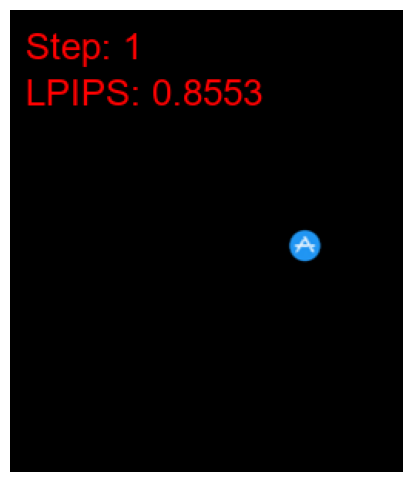

Saved debug animation to debug_can.gif


In [10]:
from torchvision.transforms.functional import to_tensor

can_path = "Logos/apple-app-store-logo.png"
can_pil = Image.open(can_path).convert('RGBA').resize((can_width_px, can_height_px))
can_rgb_full = to_tensor(can_pil.convert('RGB')).unsqueeze(0).to(device)
can_alpha_full = T.ToTensor()(can_pil.split()[-1]).unsqueeze(0).to(device)
can_rgb = downscale(can_rgb_full, downscale_factor)
can_alpha = F.interpolate(can_alpha_full, scale_factor=downscale_factor, mode='bilinear', align_corners=False)


target_tensor = to_tensor(target_pil).unsqueeze(0).to(device)  # shape: 1x3xHxW
canvas = torch.zeros_like(target_tensor).detach()              # blank canvas

canvas, loss, data = place_can_onto_canvas(
    canvas, can_rgb, can_alpha, target_tensor, lpips_loss,
    n_steps=100, lr=25.0, min_improvement=0.001,
    debug_plot=True,
    gif_path='debug_can.gif'
)

Placed can — LPIPS improved from 0.880557 to 0.854326 in 338 steps


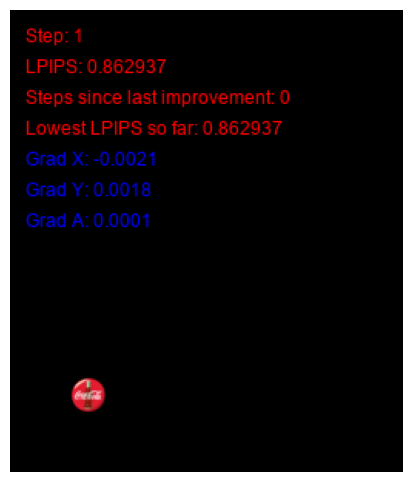

Saved debug animation to debug_can_plateau.gif
Saved LPIPS plot to lpips_trend.png


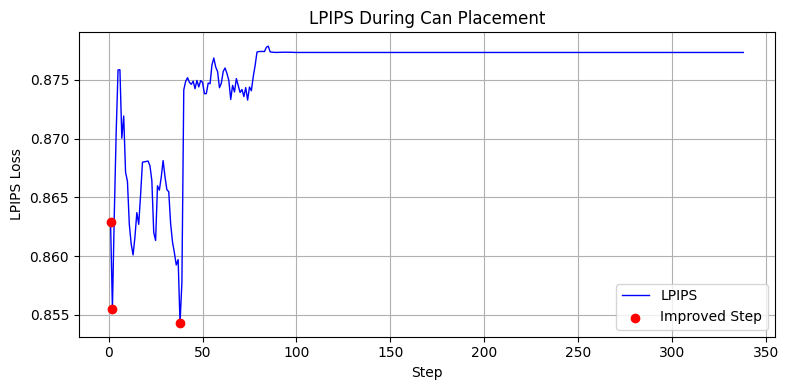

In [47]:
from torchvision.transforms.functional import to_tensor
from PIL import Image
import torch.nn.functional as F
import torchvision.transforms as T

# === Load & preprocess can image ===
can_path = "Logos/coca-cola-bottle-logo-vector-400x400.png"
can_pil = Image.open(can_path).convert('RGBA').resize((can_width_px, can_height_px))

can_rgb_full = to_tensor(can_pil.convert('RGB')).unsqueeze(0).to(device)
can_alpha_full = T.ToTensor()(can_pil.split()[-1]).unsqueeze(0).to(device)

can_rgb = F.interpolate(can_rgb_full, scale_factor=downscale_factor, mode='bilinear', align_corners=False)
can_alpha = F.interpolate(can_alpha_full, scale_factor=downscale_factor, mode='bilinear', align_corners=False)

# === Prepare target and blank canvas ===
target_tensor = to_tensor(target_pil).unsqueeze(0).to(device)
canvas = torch.zeros_like(target_tensor).detach()

# === Run placement with indefinite optimization ===
canvas, loss, data = place_can_until_plateau(
    canvas, can_rgb, can_alpha, target_tensor, lpips_loss,
    lr=100.0,
    min_improvement=0.00001,
    max_no_improve_steps=300,
    debug_plot=True,
    gif_path='debug_can_plateau.gif',
    plot_path='lpips_trend.png'
)

In [6]:
import os
import random

# Set path to your folder of can images
can_folder = 'Logos' 

# Gather image file paths (supports common image extensions)
can_paths = [
    os.path.join(can_folder, fname)
    for fname in os.listdir(can_folder)
    if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
]

# Confirm how many were found
print(f"Found {len(can_paths)} can images.")

random.shuffle(can_paths)


Found 1290 can images.


In [7]:
# Load and preprocess all cans as (RGB, Alpha) tensors
can_tensors = []

for path in can_paths:
    pil = Image.open(path).convert('RGBA').resize((can_width_px, can_height_px))
    rgb = to_tensor(pil.convert('RGB')).unsqueeze(0).to(device)
    alpha = T.ToTensor()(pil.split()[-1]).unsqueeze(0).to(device)
    can_tensors.append((rgb, alpha))


In [9]:
import random

# Start with blank canvas
canvas = torch.zeros_like(target_tensor).detach()
placements = []

# Place N cans
N = 150
profile_can_index = 0  # Choose which can to profile

for i in range(N):
    print(f"\n---- Placing can {i+1} ----")

    can_filename, (can_rgb, can_alpha) = random.choice(list(zip(can_paths, can_tensors)))

    if i == profile_can_index:
        print("Profiling this can placement...")

        with torch.profiler.profile(
            activities=[
                torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA if torch.cuda.is_available() else torch.profiler.ProfilerActivity.CPU
            ],
            schedule=torch.profiler.schedule(wait=0, warmup=0, active=1),
            on_trace_ready=torch.profiler.tensorboard_trace_handler('./profiler_logs'),
            record_shapes=True,
            with_stack=True
        ) as prof:
            canvas, loss, data = place_can_onto_canvas(
                canvas, can_rgb, can_alpha, target_tensor, lpips_loss,
                n_steps=50, lr=2.0, min_improvement=0.000
            )
            prof.step()  # Needed to finalize one step profiling

        print("Profiler trace written to ./profiler_logs (view with TensorBoard)")
    else:
        canvas, loss, data = place_can_onto_canvas(
            canvas, can_rgb, can_alpha, target_tensor, lpips_loss,
            n_steps=50, lr=2.0, min_improvement=0.000
        )

    if data:
        data['can_index'] = i + 1
        x_low, y_low = data['position']
        data['position'] = [x_low / downscale_factor, y_low / downscale_factor]
        data['angle'] = data['angle']
        data['can_filename'] = can_filename
        placements.append(data)






---- Placing can 1 ----
Profiling this can placement...
Placed can — LPIPS improved from 0.9990524649620056 to 0.9735944271087646
Profiler trace written to ./profiler_logs (view with TensorBoard)

---- Placing can 2 ----
Placed can — LPIPS improved from 0.9735944271087646 to 0.9461202621459961

---- Placing can 3 ----
Placed can — LPIPS improved from 0.9461202621459961 to 0.9153462052345276

---- Placing can 4 ----
Placed can — LPIPS improved from 0.9153462052345276 to 0.9038211703300476

---- Placing can 5 ----
Placed can — LPIPS improved from 0.9038211703300476 to 0.8869997262954712

---- Placing can 6 ----
Placed can — LPIPS improved from 0.8869997262954712 to 0.8732006549835205

---- Placing can 7 ----
Placed can — LPIPS improved from 0.8732006549835205 to 0.8732006549835205

---- Placing can 8 ----
Placed can — LPIPS improved from 0.8732006549835205 to 0.8730578422546387

---- Placing can 9 ----
Placed can — LPIPS improved from 0.8730578422546387 to 0.8711471557617188

---- Placi

In [10]:
# Save final canvas + metadata
final_image = to_pil(canvas.squeeze().cpu())
final_image.save('final_canvas.png')

import json
with open('placement_log.json', 'w') as f:
    json.dump(placements, f, indent=2)

Saved animation to reconstruction.gif


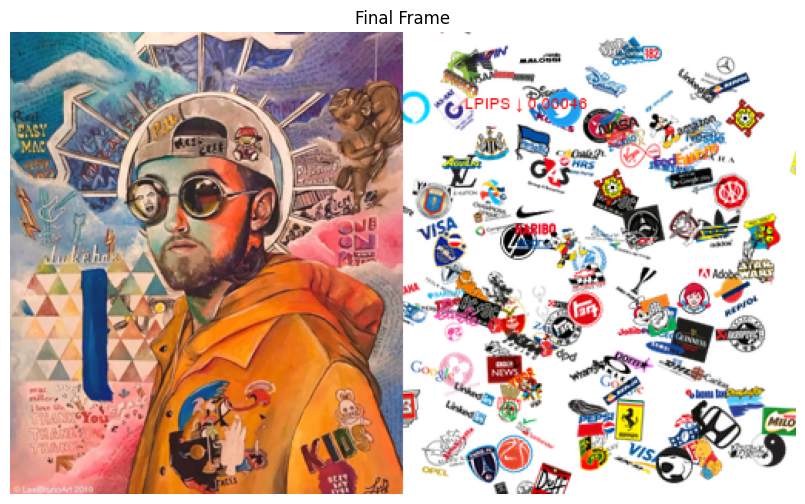

In [12]:
import json
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import os


canvas_width_px = int(canvas_width_in * dpi)
canvas_height_px = int(canvas_height_in * dpi)
can_width_px = int(can_width_in * dpi)
can_height_px = int(can_height_in * dpi)

# === Load placement data ===
with open('placement_log.json', 'r') as f:
    placements = json.load(f)

# === Load target image ===
target_img = Image.open('test-images/mac.png').convert('RGB').resize((canvas_width_px, canvas_height_px))

# === Load a font ===
try:
    font = ImageFont.truetype("arial.ttf", size=10)
except:
    font = ImageFont.load_default()

# === Initialize canvas and frame list ===
canvas = Image.new('RGBA', (canvas_width_px, canvas_height_px), (255, 255, 255, 0))
frames = []

for i, placement in enumerate(placements):
    can_path = placement["can_filename"]
    can_img = Image.open(can_path).convert("RGBA")

    # ✅ Resize to real-world pixel size
    can_img = can_img.resize((can_width_px, can_height_px), Image.LANCZOS)

    angle = placement["angle"]
    rotated = can_img.rotate(angle, expand=True, resample=Image.BICUBIC)

    x, y = placement["position"]
    paste_x = int(x - rotated.width // 2)
    paste_y = int(y - rotated.height // 2)
    canvas.paste(rotated, (paste_x, paste_y), rotated)

    # Compose side-by-side with LPIPS info
    combined = Image.new("RGB", (canvas_width_px * 2, canvas_height_px), color=(255, 255, 255))
    combined.paste(target_img, (0, 0))
    combined.paste(canvas.convert("RGB"), (canvas_width_px, 0))

    draw = ImageDraw.Draw(combined)
    lpips_val = placement.get("improvement", 0.0)
    draw.text((canvas_width_px + 40, 40), f"LPIPS ↓ {lpips_val:.5f}", font=font, fill=(255, 0, 0))

    frames.append(combined)

# === Save animation as GIF ===
gif_path = "reconstruction.gif"
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=400,
    loop=0
)
print(f"Saved animation to {gif_path}")

# === Show final frame ===
plt.figure(figsize=(12, 6))
plt.imshow(frames[-1])
plt.axis("off")
plt.title("Final Frame")
plt.show()
